In [1]:
import sys
sys.path.append('../')
from utils_models import *
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

In [2]:
max_ql = 7
max_ol = 20
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.12,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(3) ],
    computaional_states = '1,2',
    )


In [3]:
from copy import deepcopy

system_computational = system

dressed_op = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator).full()
operator_bare = system.osc.n_operator()
n_lvls = max_ol-1
for i in range(n_lvls):
    for ql in [1,2]:
        dressed_lvl_i = system.product_to_dressed[(ql, i)]
        dressed_lvl_ip1 = system.product_to_dressed[(ql, i+1)]
        first_sign = np.imag(operator_bare[i, i+1]) > 0 
        if np.imag(dressed_op[dressed_lvl_i, dressed_lvl_ip1]) < 0:
            dressed_op[dressed_lvl_i, dressed_lvl_ip1] *= -1
            dressed_op[dressed_lvl_ip1, dressed_lvl_i] *= -1

dressed_op = qutip.Qobj(dressed_op)

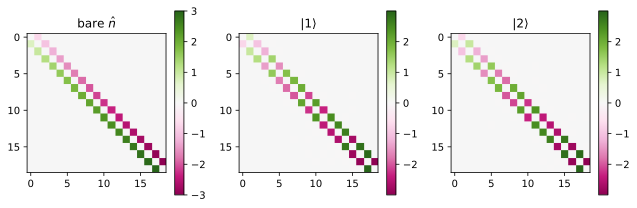

In [4]:
operator_dressed = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator, truncated_dim = 400)
# operator_dressed = dressed_op

operator_bare = system.osc.n_operator()

fig, axes = plt.subplots(1, 3, figsize=(9, 3))  # 1 row, 3 columns

array1 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array1[i, j] = np.imag(operator_bare[i, j])

array2 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array2[i, j] = np.imag(operator_dressed[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, j)]])

array3 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array3[i, j] = np.imag(operator_dressed[system.product_to_dressed[(2, i)], system.product_to_dressed[(2, j)]])

arrays = [array1,array2,array3]
titles = [r'bare $\hat{{n}}$',r'$|1\rangle$', r'$|2\rangle$']
for i, ax in enumerate(axes):
    im = ax.imshow(arrays[i], cmap='PiYG', interpolation='nearest')
    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax)  


plt.tight_layout()  # Adjust the layout to make room for the colorbar
plt.show()


# next question, is the sign in the dressed operator an error or it is what it is?

In [5]:
import scqubits.utils.spectrum_utils as spec_utils

truncated_dim = system.hilbertspace.dimension
op = system.osc.n_operator
op_in_bare_eigenbasis = False
subsys_index = 1

bare_evecs = system.hilbertspace._data["bare_evecs"][subsys_index][0]
id_wrapped_op = spec_utils.identity_wrap(
    op,
    system.hilbertspace.subsystem_list[subsys_index],
    system.hilbertspace.subsystem_list,
    op_in_eigenbasis=op_in_bare_eigenbasis,
    evecs=bare_evecs,
)
dressed_evecs = system.hilbertspace._data["evecs"][0]
dressed_op_data =  id_wrapped_op.transform(dressed_evecs).data.toarray()
dressed_op_truncated = qutip.Qobj(
    dressed_op_data[0:truncated_dim, 0:truncated_dim],
    dims=[[truncated_dim], [truncated_dim]],
)

## There's no problem with id_wrapped_op

In [6]:
for i in range(max_ol-1):
    print(id_wrapped_op.full().reshape(max_ql,max_ol,max_ql,max_ol)[1,i,1,i+1])

-0.7071067811865475j
-1j
-1.224744871391589j
-1.414213562373095j
-1.5811388300841895j
-1.732050807568877j
-1.8708286933869707j
-2j
-2.1213203435596424j
-2.23606797749979j
-2.3452078799117144j
-2.449489742783178j
-2.5495097567963922j
-2.6457513110645903j
-2.7386127875258306j
-2.82842712474619j
-2.91547594742265j
-2.9999999999999996j
-3.0822070014844885j


## There's sign change after id_wrapped_op.transform(dressed_evecs)

In [7]:
for i in range(max_ol-1):
    print(dressed_op_truncated.full()[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, i+1)]])

0.7070684533140836j
-0.9999458188202969j
-1.224678540964576j
1.414137002566321j
-1.581053269357858j
1.7319571196324213j
1.8707275411210218j
1.999891908859999j
-2.12120574350464j
2.2359472289291027j
-2.3450812906904503j
2.4493575799454095j
2.549372254891682j
2.6456086782930903j
-2.7384652103628837j
2.828274771503446j
2.9153189710136442j
-2.9998382826454075j
3.080705471140059j


In [8]:
type(id_wrapped_op)

qutip.qobj.Qobj

In [9]:
dressed_evecs[2].full()

array([[-3.21152767e-05+0.j],
       [ 0.00000000e+00+0.j],
       [-8.10852813e-06+0.j],
       [ 0.00000000e+00+0.j],
       [ 9.09183839e-12+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [-5.15823413e-04+0.j],
       [ 0.00000000e+00+0.j],
       [-9.30970559e-09+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [ 0

# The eigenstate represented in LC basis has a negative sign.

In [10]:
system.hilbertspace._data["evals"][0]

array([ -0.67502425,   1.4524949 ,   1.49601413,   2.21915865,
         3.7189799 ,   4.38898075,   5.38383601,   6.49042674,
         8.61788821,   8.66137538,   9.38429059,  10.88400955,
        11.55405664,  12.54870048,  13.65587769,  15.78328143,
        15.82673658,  16.54942257,  18.04903923,  18.71913257,
        19.71356502,  20.8213286 ,  22.94867457,  22.99209774,
        23.71455458,  25.21406894,  25.88420853,  26.87842963,
        27.98677947,  30.11406763,  30.15745886,  30.87968663,
        32.37909868,  33.04928453,  34.0432943 ,  35.1522303 ,
        37.2794606 ,  37.32281994,  38.04481871,  39.54412845,
        40.21436056,  41.20815903,  42.3176811 ,  44.44485349,
        44.48818097,  45.20995083,  46.70915825,  47.37943662,
        48.37302384,  49.48313185,  51.6102463 ,  51.65354197,
        52.37508299,  53.87418809,  54.54451271,  55.53788871,
        56.64858257,  58.77563902,  58.81890292,  59.54021518,
        61.03921795,  61.70958884,  62.70275364,  63.81